In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
import pandas as pd

data = pd.read_excel("/content/soil_data_incl_rain_v3.csv (6).xlsx")

print("Original data head:\n", data.head())
print("Original data columns:\n", data.columns)

def label_moist(x):
    if x < 50:
        return 0
    elif x < 100:
        return 1
    else:
        return 2

df = data.copy()
df = df.dropna()
df['label'] = df['Soil_Moisture'].apply(label_moist)

print("\nDataFrame head after adding 'label' and dropping NaNs:\n", df.head())
print("DataFrame columns after adding 'label':\n", df.columns)

Original data head:
                         Time   Humidity  Atmospheric_Temp  Soil_Temp  \
0  2017-06-11 21:00:21+00:00  25.252367         15.487149  12.457884   
1  2017-06-11 22:00:21+00:00  33.304246         12.115891   8.514263   
2  2017-06-11 23:00:21+00:00  24.072051         17.319203  11.913326   
3  2017-06-12 00:00:21+00:00  45.026218         15.865805  14.700958   
4  2017-06-12 01:00:21+00:00  41.490917         13.842739   8.495549   

   Soil_Moisture  Dew_Point  
0      63.077305  23.918315  
1      40.097357  31.542544  
2     100.141916  21.142841  
3      64.638742  42.217799  
4      97.964697  38.257137  
Original data columns:
 Index(['Time', 'Humidity', 'Atmospheric_Temp', 'Soil_Temp', 'Soil_Moisture',
       'Dew_Point'],
      dtype='object')

DataFrame head after adding 'label' and dropping NaNs:
                         Time   Humidity  Atmospheric_Temp  Soil_Temp  \
0  2017-06-11 21:00:21+00:00  25.252367         15.487149  12.457884   
1  2017-06-11 22:00:2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
# df is already processed in JecdUS2bqjcp, so no need to re-copy or dropna here.

print("Dataset shape after processing:", df.shape)

Dataset shape after processing: (8761, 7)


In [ ]:
X = df[['Humidity','Atmospheric_Temp','Soil_Temp','Soil_Moisture','Dew_Point']].values
y = df['label'].values

In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

n_classes = len(np.unique(y_encoded))

In [ ]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of X after scaling:", X_scaled.shape)

Shape of X after scaling: (8761, 5)


In [ ]:
# Reshape X for CNN input (num_samples, num_features, 1)
X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print("CNN Input Shape:", X_cnn.shape)

CNN Input Shape: (8761, 5, 1)


In [ ]:
# Define n_classes based on the 'label' column which now has been created
n_classes = len(np.unique(y))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Stratify to ensure proportional representation of classes
)

# One-hot encode the target variables for categorical cross-entropy
y_train_one_hot = to_categorical(y_train, num_classes=n_classes)
y_test_one_hot  = to_categorical(y_test, num_classes=n_classes)

print("X_train shape:", X_train.shape)
print("y_train_one_hot shape:", y_train_one_hot.shape)
print("X_test shape:", X_test.shape)
print("y_test_one_hot shape:", y_test_one_hot.shape)

X_train shape: (7008, 5, 1)
y_train_one_hot shape: (7008, 3)
X_test shape: (1753, 5, 1)
y_test_one_hot shape: (1753, 3)


In [ ]:
import zipfile
import pandas as pd
import os

# Path to the zip file
zip_file_path = "/content/soil moisture dataset.zip"
# Directory to extract the contents
extraction_path = "/content/extracted_soil_data"

# Create extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# Find the excel or csv file in the extracted folder
data_file_name = None
for root, dirs, files in os.walk(extraction_path):
    for file in files:
        if file.endswith(('.xlsx', '.xls', '.csv')):
            data_file_name = file
            break
    if data_file_name:
        break

if data_file_name is None:
    raise FileNotFoundError("No Excel or CSV file found in the extracted zip archive.")

# Load data from the extracted file
file_path = os.path.join(root, data_file_name)
if data_file_name.endswith(('.xlsx', '.xls')):
    data = pd.read_excel(file_path)
elif data_file_name.endswith('.csv'):
    data = pd.read_csv(file_path)
else:
    raise ValueError("Unsupported file format.")

# Define function to label moisture
def label_moist(x):
    if x < 50:
        return 0
    elif x < 100:
        return 1
    else:
        return 2

# Create df and add 'label' column
df = data.copy()
df = df.dropna()
df['label'] = df['Soil_Moisture'].apply(label_moist)

# Define X and y from df
X = df[['Humidity','Atmospheric_Temp','Soil_Temp','Soil_Moisture','Dew_Point']].values
y = df['label'].values

# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Determine number of classes
n_classes = len(np.unique(y_encoded))

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape X for CNN input (num_samples, num_features, 1)
X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# One-hot encode the target variables for categorical cross-entropy
y_train_one_hot = to_categorical(y_train, num_classes=n_classes)
y_test_one_hot = to_categorical(y_test, num_classes=n_classes)

In [ ]:
model = Sequential()

model.add(Conv1D(32, 2, activation='relu', input_shape=(X_cnn.shape[1],1)))
model.add(MaxPooling1D(2))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(n_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Conv1D(5, 2, activation='relu', input_shape=(X_train.shape[1], 1), padding='same'),
    MaxPooling1D(2),
    Dropout(0.4), # Increased dropout rate from 0.3 to 0.4

    Flatten(),
    Dense(5, activation='relu'),
    Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

history = model.fit(
    X_train,
    y_train_one_hot,
    epochs=100, # Increased epochs to allow early stopping to work
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

loss, accuracy = model.evaluate(X_test, y_test_one_hot)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 5, 5)           │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 2, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 2, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88 (352.00 B)

 Trainable params: 88 (352.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4340 - loss: 1.1388 - val_accuracy: 0.4757 - val_loss: 1.0645
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4980 - loss: 1.0438 - val_accuracy: 0.5492 - val_loss: 0.9812
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5681 - loss: 0.9461 - val_accuracy: 0.6377 - val_loss: 0.8354
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6200 - loss: 0.8578 - val_accuracy: 0.6854 - val_loss: 0.7324
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6324 - loss: 0.8255 - val_accuracy: 0.6933 - val_loss: 0.6957
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6456 - loss: 0.8019 - val_accuracy: 0.7161 - val_loss: 0.6647
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6547 - loss: 0.7857 - val_accuracy: 0.7268 - val_loss: 0.6490
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6504 - loss: 0.7915 - val_accu

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


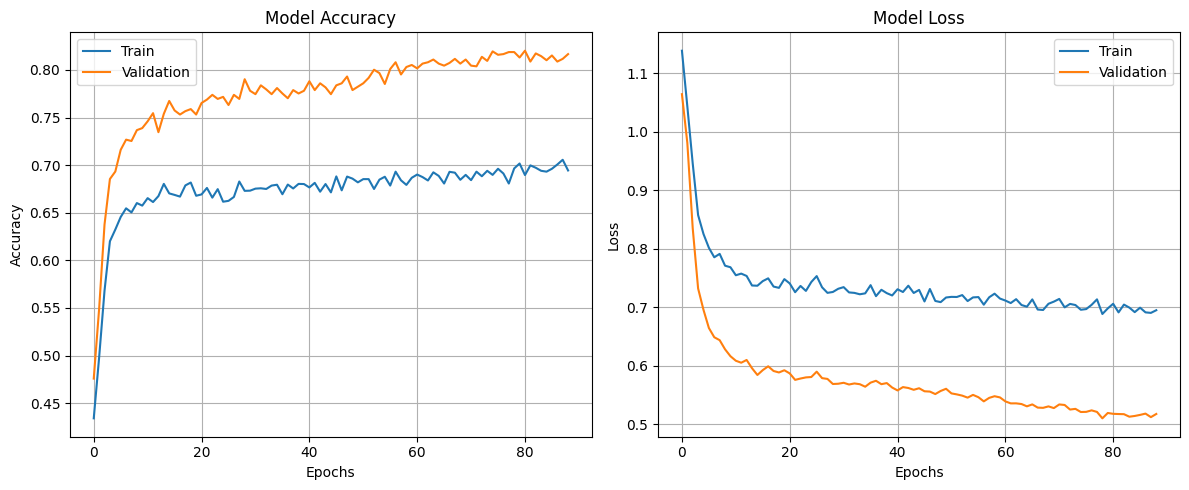

In [ ]:
import matplotlib.pyplot as plt

# Check if history exists
print(history.history.keys())

plt.figure(figsize=(12, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# Predict first 10 samples
predictions = model.predict(X_test[:10])

# Convert prediction probabilities to class index
predicted_classes = np.argmax(predictions, axis=1)

# Convert one-hot encoded y_test to class index
true_classes = np.argmax(y_test_one_hot[:10], axis=1)

# Convert class numbers back to soil labels
true_labels = encoder.inverse_transform(true_classes)
predicted_labels = encoder.inverse_transform(predicted_classes)

print("\nPredictions for Soil Moisture Dataset:")
print("True labels:      ", true_labels)
print("Predicted labels: ", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

Predictions for Soil Moisture Dataset:
True labels:       [2 1 2 2 1 2 1 1 1 0]
Predicted labels:  [2 1 1 2 1 2 1 1 1 0]


In [ ]:
loss, acc = model.evaluate(X_test, y_test_one_hot)
print("Test Accuracy:", acc*100,"%")

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8289 - loss: 0.4620
Test Accuracy: 82.88648128509521 %


In [ ]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions,axis=1)

true_classes = np.argmax(y_test_one_hot,axis=1)

num_samples_to_plot = 40

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


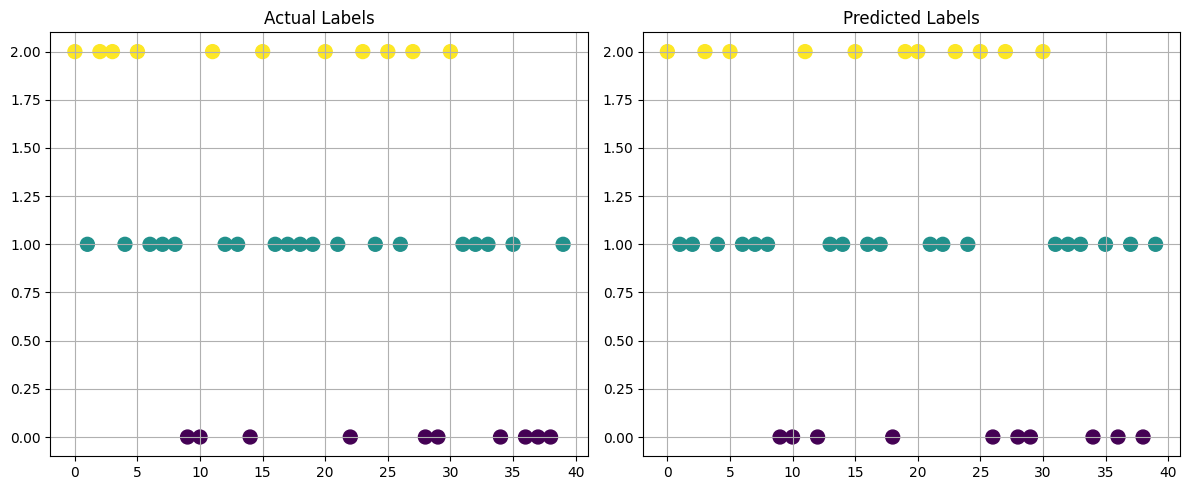

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(range(num_samples_to_plot),
            true_classes[:num_samples_to_plot],
            c=true_classes[:num_samples_to_plot],
            cmap='viridis',s=100)
plt.title("Actual Labels")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(range(num_samples_to_plot),
            predicted_classes[:num_samples_to_plot],
            c=predicted_classes[:num_samples_to_plot],
            cmap='viridis',s=100)
plt.title("Predicted Labels")
plt.grid(True)

plt.tight_layout()
plt.show()

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


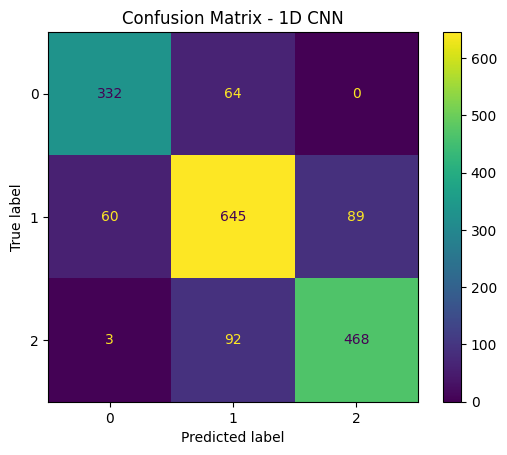

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predict on test data
y_pred = model.predict(X_test)

# Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_one_hot, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - 1D CNN")
plt.show()